# Monte Carlo Approximation of the Long-Only Frontier

Aim - To draw long-only portfolios at random from the simplex via **five samplers** (Dirichlet $\alpha=1$, Dirichlet $\alpha=0.3$, sparse face, tilted Dirichlet, mixed), compare their best Sharpe and return gap against the **iterative active-set long-only frontier** swept inline across a wide $\gamma$ range, and quantify how the sampling distribution and sample size $M$ control the approximation quality.

Also refer to [README](README.md).


## Monte Carlo Is a Sampler, Not a Solver

Monte Carlo generates feasible long-only portfolios by drawing weight vectors from a distribution on the unit simplex. Each draw is evaluated by return $\mu_p = w^\top \mu$ and volatility $\sigma_p = \sqrt{w^\top \Sigma w}$; the resulting cloud approximates the feasible region.

The efficient frontier is a one-dimensional curve on the *boundary* of the image of the simplex under $w \mapsto (\sigma_p, \mu_p)$. Random sampling from the simplex interior rarely lands on this boundary. The boundary is a measure-zero set in $\Delta_N$; uninformed sampling almost surely misses it. Samplers that bias mass toward simplex corners and faces approximate the frontier better than uniform interior sampling, but none of them are a substitute for a convex solver when one is available.


## Data, Setup, and the 20-Asset Universe

The notebook uses **20 NSE-listed Indian stocks** across **eight sectors** — the same universe as `01_theory.ipynb` and `02_solvers.ipynb`. $\hat \mu$ and $\hat \Sigma$ computed identically so the frontier from `02_solvers.ipynb` can be loaded as-is.

- **Information technology:** TCS, INFY, WIPRO
- **Banking and financials:** HDFCBANK, ICICIBANK, KOTAKBANK
- **Energy:** RELIANCE, ONGC, BPCL
- **Consumer staples:** HINDUNILVR, ITC, NESTLEIND
- **Industrials and autos:** MARUTI, LT
- **Pharma:** SUNPHARMA, DRREDDY
- **Metals:** TATASTEEL, JSWSTEEL
- **Telecom:** BHARTIARTL, INDUSTOWER

In [25]:
from pathlib import Path
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10

REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "pyproject.toml").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "1_classical_baseline" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(seed=20260523)

START_DATE = "2019-01-01"
END_DATE   = "2024-12-31"

SECTORS = {
    "Information technology":  ["TCS.NS", "INFY.NS", "WIPRO.NS"],
    "Banking and financials":  ["HDFCBANK.NS", "ICICIBANK.NS", "KOTAKBANK.NS"],
    "Energy":                  ["RELIANCE.NS", "ONGC.NS", "BPCL.NS"],
    "Consumer staples":        ["HINDUNILVR.NS", "ITC.NS", "NESTLEIND.NS"],
    "Industrials and autos":   ["MARUTI.NS", "LT.NS"],
    "Pharma":                  ["SUNPHARMA.NS", "DRREDDY.NS"],
    "Metals":                  ["TATASTEEL.NS", "JSWSTEEL.NS"],
    "Telecom":                 ["BHARTIARTL.NS", "INDUSTOWER.NS"],
}
TICKERS = [t for names in SECTORS.values() for t in names]

Download, compute simple returns, build $\hat\mu$ and $\hat\Sigma$.

In [26]:
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)["Close"]
raw = raw.dropna(how="all")
raw = raw.loc[:, raw.isna().mean() < 0.1].dropna()

asset_names = list(raw.columns)
n_assets    = len(asset_names)
ret         = raw.pct_change().dropna().to_numpy()

mu_hat    = 252.0 * ret.mean(axis=0)
Sigma_hat = 252.0 * np.cov(ret, rowvar=False)
w_eq      = np.full(n_assets, 1.0 / n_assets)

print(f"window: {START_DATE} to {END_DATE}")
print(f"assets: {n_assets}, daily rows: {ret.shape[0]}")
print(f"mu range: [{mu_hat.min():.4f}, {mu_hat.max():.4f}]")

window: 2019-01-01 to 2024-12-31
assets: 20, daily rows: 1479
mu range: [0.0877, 0.3380]


## Long-Only Feasible Set and Portfolio Metrics

Every Monte Carlo draw is a point on the long-only simplex

$$\Delta_N = \{ w \in \mathbb R^N : w_i \ge 0, \; \mathbf 1^\top w = 1 \}.$$

$\Delta_N$ is $(N-1)$-dimensional. For $N = 20$ it is a 19-dimensional polytope inside $\mathbb R^{20}$. Its $\binom{N}{k}$ faces of dimension $k - 1$ correspond to portfolios concentrated on exactly $k$ assets.

For each sampled $w$ compute return, volatility, gross Sharpe (risk-free rate zero), and the **effective number of assets** $N_{\text{eff}} = 1 / \sum_i w_i^2$. Equal-weight gives $N_{\text{eff}} = N$; a single-asset portfolio gives $N_{\text{eff}} = 1$.

In [27]:
def portfolio_metrics(W, mu, Sigma):
    # W is (M, N) — returns (ret, vol, sharpe, n_eff) one row per sample
    ret    = W @ mu
    var    = np.einsum("ki,ij,kj->k", W, Sigma, W)
    vol    = np.sqrt(np.maximum(var, 0.0))
    sharpe = np.where(vol > 0, ret / vol, np.nan)
    n_eff  = 1.0 / np.einsum("ki,ki->k", W, W)
    return ret, vol, sharpe, n_eff

Equal-weight as a reference point on every cloud plot.

In [28]:
vol_eq = float(np.sqrt(w_eq @ Sigma_hat @ w_eq))
ret_eq = float(mu_hat @ w_eq)
print(f"equal-weight: return={ret_eq:.4%}, vol={vol_eq:.4%}")

equal-weight: return=20.1225%, vol=17.3651%


A shared cloud-plot helper avoids repeating the same scatter/legend/save scaffolding across four sampler sections.

In [29]:
def cloud_plot(ax, vol, ret, sharpe, frontier_df, best_idx, title, n_pts):
    sc = ax.scatter(vol, ret, s=1, alpha=0.15, c=sharpe, cmap="viridis", rasterized=True)
    ax.plot(frontier_df["volatility"], frontier_df["return"], "-", color="black", lw=2, label="long-only frontier")
    ax.scatter([vol_eq], [ret_eq], color="orange", marker="s", s=60, zorder=5, label="equal-weight")
    ax.scatter([vol[best_idx]], [ret[best_idx]], color="red", marker="*", s=200, zorder=6, label="best sampled Sharpe")
    ax.set_xlabel("annualised volatility")
    ax.set_ylabel("annualised return")
    ax.set_title(f"{title}  (n={n_pts:,})")
    return sc

## Reference Frontier — Iterative Active-Set, Wide $\gamma$ Range

The reference frontier is computed inline by the **iterative active-set** method from `01_theory.ipynb` (KKT-driven, polynomial cost — not the $O(2^N)$ brute-force enumeration). The CVXPY-form sweep in `02_solvers.ipynb` only ranges $\gamma \in [0.01, 5]$, which covers the low-volatility end of the frontier. Monte Carlo clouds reach higher volatilities, so a wider grid $\gamma \in [10^{-3}, 10^{2}]$ is used here to extend the curve out to the high-volatility/high-return corner where the samplers actually populate.

In [30]:
def solve_free_set(mu_vec, sigma_mat, free, gamma):
    # equality-constrained closed form on the indices in `free`
    idx     = np.array(sorted(free), dtype=int)
    mu_s    = mu_vec[idx]
    sigma_s = sigma_mat[np.ix_(idx, idx)]
    ones    = np.ones(len(idx))
    inv_one = np.linalg.solve(sigma_s, ones)
    inv_mu  = np.linalg.solve(sigma_s, mu_s)
    A_s = float(ones @ inv_one)
    B_s = float(ones @ inv_mu)
    eta = (B_s - 2.0 * gamma) / A_s
    weights_s = (inv_mu - eta * inv_one) / (2.0 * gamma)
    weights = np.zeros(len(mu_vec))
    weights[idx] = weights_s
    return weights, eta

In [31]:
def active_set_utility(mu_vec, sigma_mat, gamma, initial_free=None, tol=1e-9, max_iter=500):
    n    = len(mu_vec)
    free = set(range(n)) if not initial_free else set(initial_free)
    visited = set()
    last_feasible_weights = None
    for iteration in range(1, max_iter + 1):
        state = tuple(sorted(free))
        if state in visited:
            w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
            return {"weights": w_out, "iterations": iteration, "converged": False, "reason": "cycle"}
        visited.add(state)
        weights, eta = solve_free_set(mu_vec, sigma_mat, sorted(free), gamma)
        free_weights = np.array([weights[i] for i in sorted(free)])
        if free_weights.min() < -tol:
            remove_asset = sorted(free)[int(np.argmin(free_weights))]
            free.remove(remove_asset)
            if not free:
                return {"weights": np.ones(n) / n, "iterations": iteration, "converged": False, "reason": "empty_free_set"}
            continue
        weights[weights < tol] = 0.0
        weights = weights / weights.sum()
        last_feasible_weights = weights.copy()
        gradient = mu_vec - 2.0 * gamma * sigma_mat @ weights
        inactive = [i for i in range(n) if i not in free]
        if inactive:
            violations = np.array([gradient[i] - eta for i in inactive])
            if violations.max() > tol:
                free.add(inactive[int(np.argmax(violations))])
                continue
        return {"weights": weights, "iterations": iteration, "converged": True, "reason": "kkt"}
    w_out = last_feasible_weights if last_feasible_weights is not None else np.ones(n) / n
    return {"weights": w_out, "iterations": max_iter, "converged": False, "reason": "max_iter"}

Sweep $\gamma$ on a wide log-spaced grid. Active-set uses the form $\max_w \mu^\top w - \gamma w^\top \Sigma w$ — the same $\gamma$ knob used everywhere else in `01_theory.ipynb`. Low $\gamma$ → high-return / high-vol corner; high $\gamma$ → minimum-variance portfolio.

In [32]:
GAMMA_GRID_WIDE = np.geomspace(1e-3, 1e2, 400)

t0 = time.perf_counter()
rows, free_start = [], None
for g in GAMMA_GRID_WIDE:
    r = active_set_utility(mu_hat, Sigma_hat, float(g), initial_free=free_start)
    wv = r["weights"]
    free_start = set(np.flatnonzero(wv > 1e-8)) if r["converged"] else None
    rows.append({
        "gamma":      float(g),
        "return":     float(mu_hat @ wv),
        "volatility": float(np.sqrt(max(wv @ Sigma_hat @ wv, 0.0))),
    })
solver_time_s = time.perf_counter() - t0

frontier_df = (pd.DataFrame(rows)
               .drop_duplicates(subset="volatility")
               .sort_values("volatility")
               .reset_index(drop=True))
print(f"active-set frontier swept: {len(frontier_df)} unique points, "
      f"vol range [{frontier_df['volatility'].min():.4f}, {frontier_df['volatility'].max():.4f}]")
print(f"active-set sweep time: {solver_time_s:.3f} s for {len(GAMMA_GRID_WIDE)} gamma values")

frontier_sharpe = (frontier_df["return"] / frontier_df["volatility"]).max()
print(f"frontier best Sharpe: {frontier_sharpe:.4f}")

active-set frontier swept: 202 unique points, vol range [0.1478, 0.2972]
active-set sweep time: 0.102 s for 400 gamma values
frontier best Sharpe: 1.5386


## Sampler: Dirichlet $\alpha = 1$

The Dirichlet distribution is the canonical probability distribution on $\Delta_N$:

$$w \sim \mathrm{Dirichlet}(\alpha \mathbf 1_N).$$

At $\alpha = 1$ it is uniform on $\Delta_N$ — every interior point has the same density. Sounds ideal but is not. For $N = 20$ the per-coordinate variance is $\frac{N-1}{N^2(N+1)} \approx 0.0022$, so draws cluster sharply around the equal-weight portfolio. Corners and edges of $\Delta_N$ — where the efficient frontier lives — are visited rarely.

In [33]:
def sample_dirichlet(rng, N, M, alpha=1.0):
    return rng.dirichlet(np.full(N, alpha), size=M)

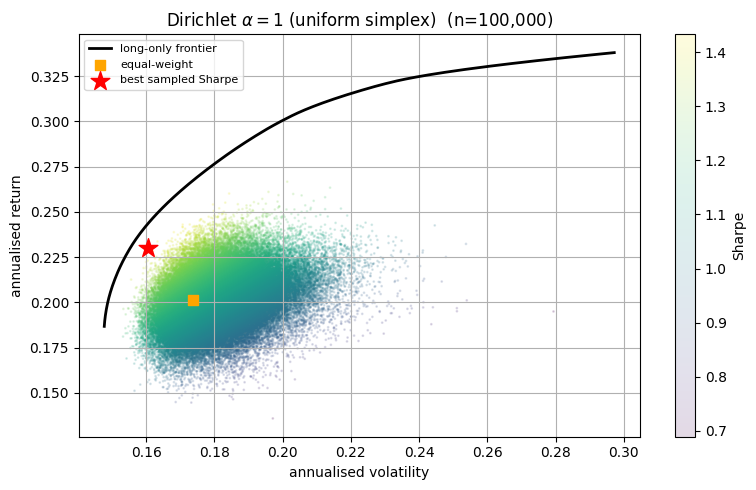

best Sharpe (Dirichlet α=1): 1.4327  vol=16.0513%  N_eff=9.9


In [34]:
M_CLOUD = 100_000

t0 = time.perf_counter()
W_d1 = sample_dirichlet(RNG, n_assets, M_CLOUD, alpha=1.0)
time_d1 = time.perf_counter() - t0
ret_d1, vol_d1, shr_d1, neff_d1 = portfolio_metrics(W_d1, mu_hat, Sigma_hat)
best_d1 = int(np.nanargmax(shr_d1))

fig, ax = plt.subplots(figsize=(8, 5))
sc = cloud_plot(ax, vol_d1, ret_d1, shr_d1, frontier_df, best_d1,
                r"Dirichlet $\alpha=1$ (uniform simplex)", M_CLOUD)
fig.colorbar(sc, ax=ax).set_label("Sharpe")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_dirichlet_alpha1_cloud.png", dpi=120)
plt.show()
print(f"best Sharpe (Dirichlet α=1): {shr_d1[best_d1]:.4f}  vol={vol_d1[best_d1]:.4%}  N_eff={neff_d1[best_d1]:.1f}")

## Sampler: Concentrated Dirichlet $\alpha = 0.3$

Dropping $\alpha$ below 1 pushes Dirichlet mass toward the corners and faces:

- $\alpha < 1$: mass concentrates toward corners of $\Delta_N$
- $\alpha = 1$: uniform on $\Delta_N$
- $\alpha > 1$: mass concentrates toward the centre (equal-weight)

Efficient portfolios on the long-only frontier are often concentrated on a small subset of names, so $\alpha = 0.3$ samples them more often than $\alpha = 1$. The trade-off: low-volatility diversified portfolios get under-sampled.

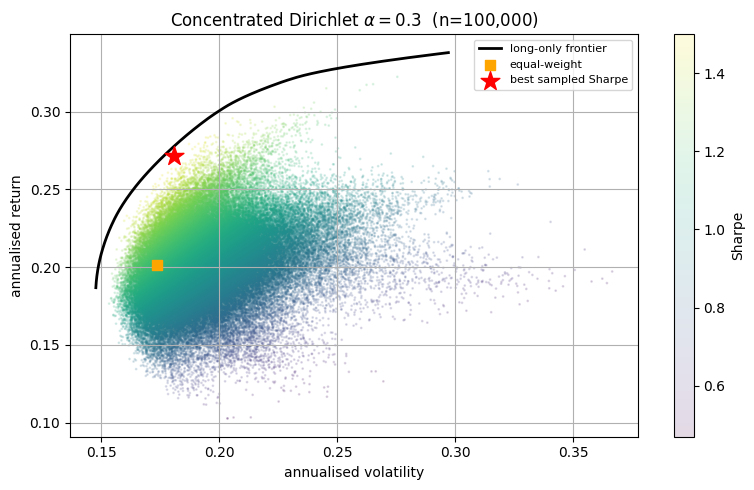

best Sharpe (Dirichlet α=0.3): 1.4997  vol=18.1033%  N_eff=4.5


In [35]:
t0 = time.perf_counter()
W_d03 = sample_dirichlet(RNG, n_assets, M_CLOUD, alpha=0.3)
time_d03 = time.perf_counter() - t0
ret_d03, vol_d03, shr_d03, neff_d03 = portfolio_metrics(W_d03, mu_hat, Sigma_hat)
best_d03 = int(np.nanargmax(shr_d03))

fig, ax = plt.subplots(figsize=(8, 5))
sc = cloud_plot(ax, vol_d03, ret_d03, shr_d03, frontier_df, best_d03,
                r"Concentrated Dirichlet $\alpha=0.3$", M_CLOUD)
fig.colorbar(sc, ax=ax).set_label("Sharpe")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_concentrated_cloud.png", dpi=120)
plt.show()
print(f"best Sharpe (Dirichlet α=0.3): {shr_d03[best_d03]:.4f}  vol={vol_d03[best_d03]:.4%}  N_eff={neff_d03[best_d03]:.1f}")

## Sampler: Sparse Face

Instead of biasing the whole vector, pick a subset of $k$ assets uniformly at random and then sample weights for those assets from $\mathrm{Dirichlet}(\mathbf 1_k)$. Everything else stays at zero.

$$K \subset \{1, \ldots, N\}, \; |K| = k, \quad w_i = 0 \;\forall\, i \notin K, \quad (w_i)_{i \in K} \sim \mathrm{Dirichlet}(\mathbf 1_k).$$

This draws directly from the $(k-1)$-dimensional face of $\Delta_N$. Run four $k$ values, $k \in \{2, 3, 5, 8\}$, to see how face dimension trades off with how often the best face is found.

In [36]:
def sample_sparse_face(rng, N, M, k):
    # for each row pick k of N columns via argpartition on uniform noise (vectorised)
    noise = rng.random((M, N))
    cols  = np.argpartition(noise, k, axis=1)[:, :k]
    sub   = rng.dirichlet(np.ones(k), size=M)
    W     = np.zeros((M, N))
    W[np.arange(M)[:, None], cols] = sub
    return W

k=2: best Sharpe=1.4101  N_eff=2.0
k=3: best Sharpe=1.4731  N_eff=2.7
k=5: best Sharpe=1.5112  N_eff=3.7
k=8: best Sharpe=1.4956  N_eff=5.3


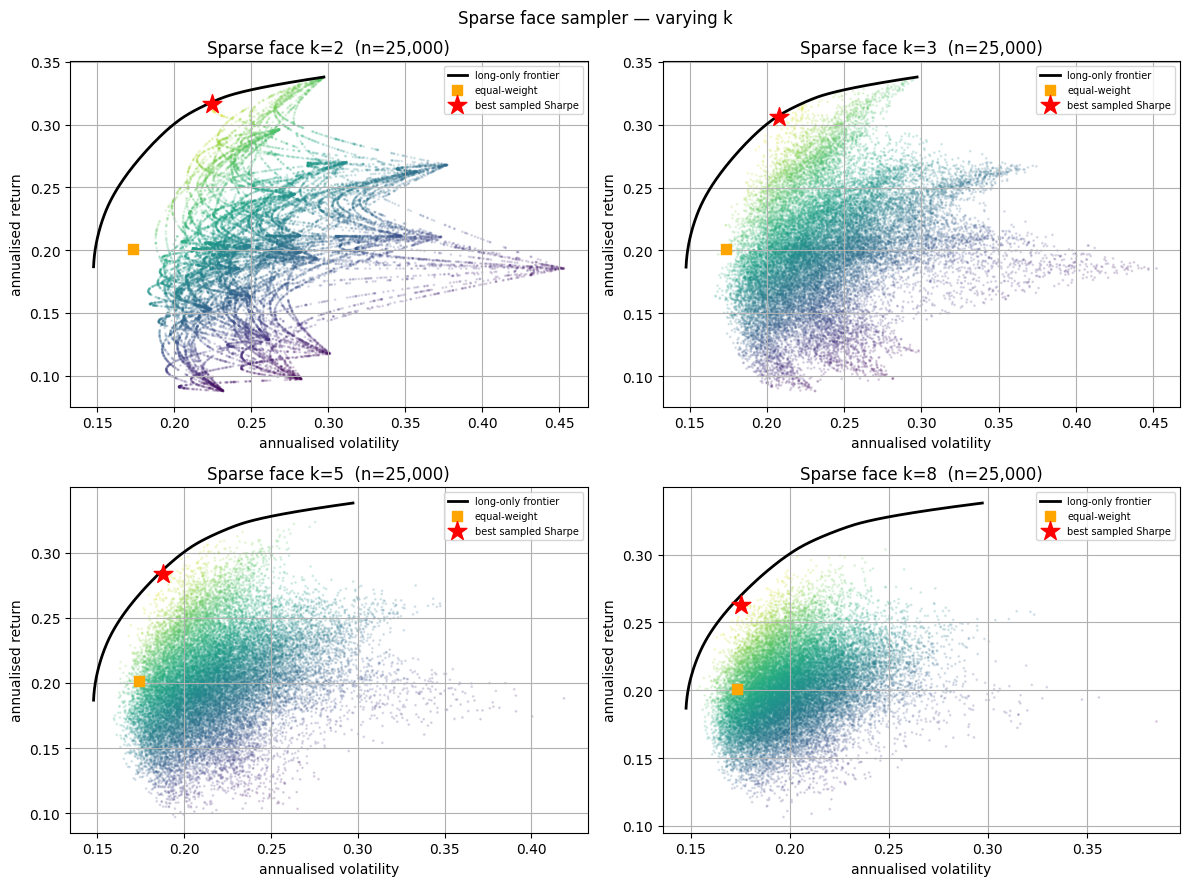

In [37]:
K_VALUES = [2, 3, 5, 8]
M_SPARSE = M_CLOUD // len(K_VALUES)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
sparse_results = {}
time_sparse_union = 0.0
for ax, k in zip(axes.ravel(), K_VALUES):
    t0 = time.perf_counter()
    Wk = sample_sparse_face(RNG, n_assets, M_SPARSE, k)
    time_sparse_union += time.perf_counter() - t0
    rk, vk, sk, nk = portfolio_metrics(Wk, mu_hat, Sigma_hat)
    best_k = int(np.nanargmax(sk))
    sparse_results[k] = {"W": Wk, "ret": rk, "vol": vk, "shr": sk, "neff": nk, "best": best_k}
    cloud_plot(ax, vk, rk, sk, frontier_df, best_k, f"Sparse face k={k}", M_SPARSE)
    ax.legend(fontsize=7)
    print(f"k={k}: best Sharpe={sk[best_k]:.4f}  N_eff={nk[best_k]:.1f}")

fig.suptitle("Sparse face sampler — varying k", fontsize=12)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_sparse_face_clouds.png", dpi=120)
plt.show()

Union all four $k$ groups into a single $4 \times M_{\text{SPARSE}} = M_{\text{CLOUD}}$ sample so the sparse sampler can be compared on the same budget as the others.

In [38]:
W_sparse_union    = np.vstack([sparse_results[k]["W"]    for k in K_VALUES])
ret_sparse_union  = np.concatenate([sparse_results[k]["ret"]  for k in K_VALUES])
vol_sparse_union  = np.concatenate([sparse_results[k]["vol"]  for k in K_VALUES])
shr_sparse_union  = np.concatenate([sparse_results[k]["shr"]  for k in K_VALUES])
neff_sparse_union = np.concatenate([sparse_results[k]["neff"] for k in K_VALUES])
best_sparse_union = int(np.nanargmax(shr_sparse_union))
print(f"sparse_face_union: best Sharpe={shr_sparse_union[best_sparse_union]:.4f}  "
      f"N_eff={neff_sparse_union[best_sparse_union]:.1f}")

sparse_face_union: best Sharpe=1.5112  N_eff=3.7


## Sampler: Tilted Dirichlet

The samplers above are blind — they do not use $\hat\mu$ or $\hat\Sigma$ at all. A small amount of information helps. The **tilted** sampler builds a Dirichlet concentration vector $\boldsymbol \alpha$ that puts more mass on assets with higher per-asset Sharpe ratio $s_i = \mu_i / \sigma_i$:

$$\alpha_i = \alpha_0 + \kappa \cdot \max(0, \, s_i - \bar s), \qquad w \sim \mathrm{Dirichlet}(\boldsymbol \alpha).$$

$\alpha_0$ is the baseline concentration (small → corners); $\kappa$ is the tilt strength. The expected weight per asset scales with $\alpha_i$, so high-Sharpe names dominate without ever forcing $w_i = 0$. Cheap, no solver call, big push toward the high-Sharpe end of the frontier.

In [39]:
def sample_tilted_dirichlet(rng, N, M, mu, Sigma, alpha0=0.2, kappa=4.0):
    sharpe_i = mu / np.sqrt(np.diag(Sigma))
    tilt     = np.maximum(0.0, sharpe_i - sharpe_i.mean())
    alpha    = alpha0 + kappa * tilt
    return rng.dirichlet(alpha, size=M)

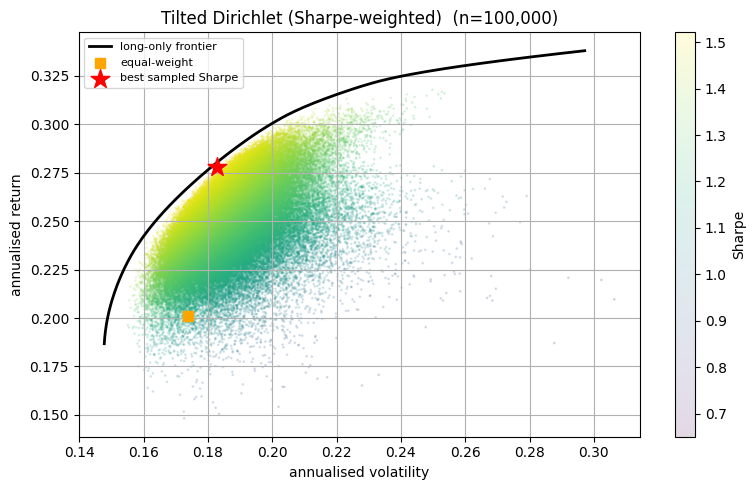

best Sharpe (tilted): 1.5210  vol=18.2819%  N_eff=4.9


In [40]:
t0 = time.perf_counter()
W_tilt = sample_tilted_dirichlet(RNG, n_assets, M_CLOUD, mu_hat, Sigma_hat)
time_tilt = time.perf_counter() - t0
ret_tilt, vol_tilt, shr_tilt, neff_tilt = portfolio_metrics(W_tilt, mu_hat, Sigma_hat)
best_tilt = int(np.nanargmax(shr_tilt))

fig, ax = plt.subplots(figsize=(8, 5))
sc = cloud_plot(ax, vol_tilt, ret_tilt, shr_tilt, frontier_df, best_tilt,
                "Tilted Dirichlet (Sharpe-weighted)", M_CLOUD)
fig.colorbar(sc, ax=ax).set_label("Sharpe")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_tilted_cloud.png", dpi=120)
plt.show()
print(f"best Sharpe (tilted): {shr_tilt[best_tilt]:.4f}  vol={vol_tilt[best_tilt]:.4%}  N_eff={neff_tilt[best_tilt]:.1f}")

## Sampler: Mixed

Combine the strengths of the four previous samplers in one mixture. Reweighted to push more mass toward the boundary and toward high-Sharpe assets:

$$20\% \, \mathrm{Dirichlet}(\alpha=1) \; + \; 20\% \, \mathrm{Dirichlet}(\alpha=0.3) \; + \; 30\% \, \text{sparse face } k \in \{2, 3, 5\} \; + \; 30\% \, \text{tilted Dirichlet}.$$

The $\alpha=1$ component keeps broad interior coverage. The other three components concentrate mass near the frontier — sparse face on low-dimensional faces, tilted on high-Sharpe directions.

In [41]:
def sample_mixed(rng, N, M, mu=None, Sigma=None):
    m1 = int(M * 0.20)
    m2 = int(M * 0.20)
    m3 = int(M * 0.30)
    m4 = M - m1 - m2 - m3
    parts = [
        sample_dirichlet(rng, N, m1, 1.0),
        sample_dirichlet(rng, N, m2, 0.3),
    ]
    # sparse face with smaller k preferred
    k_options = np.array([2, 3, 5])
    k_assign  = rng.choice(k_options, size=m3)
    W_sparse  = np.zeros((m3, N))
    for k in k_options:
        mask = k_assign == k
        mc   = int(mask.sum())
        if mc > 0:
            W_sparse[mask] = sample_sparse_face(rng, N, mc, k)
    parts.append(W_sparse)
    # tilted component (requires mu, Sigma)
    if mu is not None and Sigma is not None:
        parts.append(sample_tilted_dirichlet(rng, N, m4, mu, Sigma))
    else:
        parts.append(sample_dirichlet(rng, N, m4, 0.3))
    out = np.vstack(parts)
    rng.shuffle(out)
    return out

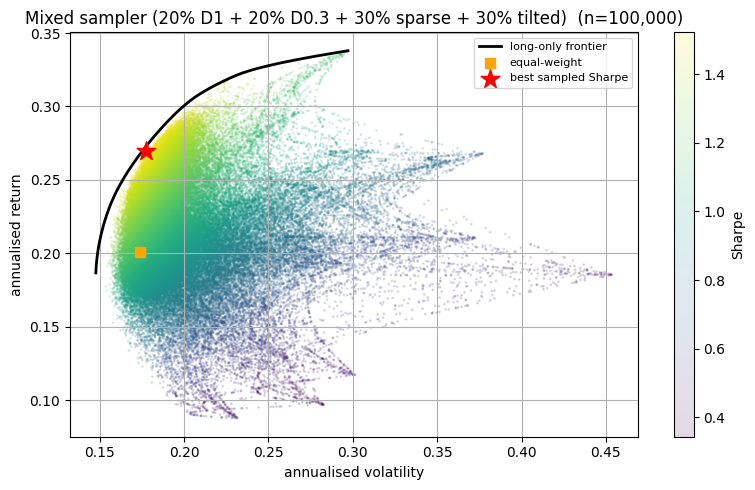

best Sharpe (mixed): 1.5220  vol=17.7334%  N_eff=5.8


In [42]:
t0 = time.perf_counter()
W_mix = sample_mixed(RNG, n_assets, M_CLOUD, mu_hat, Sigma_hat)
time_mix = time.perf_counter() - t0
ret_mix, vol_mix, shr_mix, neff_mix = portfolio_metrics(W_mix, mu_hat, Sigma_hat)
best_mix = int(np.nanargmax(shr_mix))

fig, ax = plt.subplots(figsize=(8, 5))
sc = cloud_plot(ax, vol_mix, ret_mix, shr_mix, frontier_df, best_mix,
                "Mixed sampler (20% D1 + 20% D0.3 + 30% sparse + 30% tilted)", M_CLOUD)
fig.colorbar(sc, ax=ax).set_label("Sharpe")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_mixed_cloud.png", dpi=120)
plt.show()
print(f"best Sharpe (mixed): {shr_mix[best_mix]:.4f}  vol={vol_mix[best_mix]:.4%}  N_eff={neff_mix[best_mix]:.1f}")

## Sampler Comparison

Five samplers, fixed budget $M = 100{,}000$ each. Record best Sharpe, return, volatility, concentration, gap to the frontier's best $\gamma$-grid Sharpe, and **sample-draw wall time**. The active-set sweep time across `GAMMA_GRID_WIDE` (400 $\gamma$ values) is shown alongside as the solver baseline. A `sharpe_gap` near zero means the sample happened to land near the tangency portfolio — not a guarantee of optimality.

In [43]:
sampler_results = {
    "dirichlet_alpha1":   (ret_d1,   vol_d1,   shr_d1,   neff_d1,   best_d1,   time_d1),
    "dirichlet_alpha0.3": (ret_d03,  vol_d03,  shr_d03,  neff_d03,  best_d03,  time_d03),
    "sparse_face_union":  (ret_sparse_union, vol_sparse_union, shr_sparse_union,
                           neff_sparse_union, best_sparse_union, time_sparse_union),
    "tilted":             (ret_tilt, vol_tilt, shr_tilt, neff_tilt, best_tilt,  time_tilt),
    "mixed":              (ret_mix,  vol_mix,  shr_mix,  neff_mix,  best_mix,   time_mix),
}

comp_rows = []
for name, (r, v, s, n, bi, t_draw) in sampler_results.items():
    comp_rows.append({
        "sampler":              name,
        "samples":              M_CLOUD,
        "best_sharpe":          float(s[bi]),
        "best_return":          float(r[bi]),
        "best_volatility":      float(v[bi]),
        "min_volatility":       float(v.min()),
        "median_n_eff":         float(np.median(n)),
        "best_n_eff":           float(n[bi]),
        "frontier_best_sharpe": float(frontier_sharpe),
        "sharpe_gap":           float(frontier_sharpe - s[bi]),
        "draw_time_s":          float(t_draw),
    })

# solver baseline as last row
comp_rows.append({
    "sampler":              "active_set_solver",
    "samples":              len(GAMMA_GRID_WIDE),
    "best_sharpe":          float(frontier_sharpe),
    "best_return":          float(frontier_df.loc[(frontier_df["return"] / frontier_df["volatility"]).idxmax(), "return"]),
    "best_volatility":      float(frontier_df.loc[(frontier_df["return"] / frontier_df["volatility"]).idxmax(), "volatility"]),
    "min_volatility":       float(frontier_df["volatility"].min()),
    "median_n_eff":         np.nan,
    "best_n_eff":           np.nan,
    "frontier_best_sharpe": float(frontier_sharpe),
    "sharpe_gap":           0.0,
    "draw_time_s":          float(solver_time_s),
})

comp_df = pd.DataFrame(comp_rows)
comp_df.to_csv(RESULTS_DIR / "monte_carlo_sampler_comparison.csv", index=False)
display(comp_df[["sampler", "samples", "best_sharpe", "sharpe_gap", "best_n_eff", "draw_time_s"]])

,sampler,samples,best_sharpe,sharpe_gap,best_n_eff,draw_time_s
0,dirichlet_alpha1,100000,1.432651,0.105945,9.862077,0.061820
1,dirichlet_alpha0.3,100000,1.499721,0.038874,4.541504,0.238691
2,sparse_face_union,100000,1.511239,0.027356,3.669721,0.196293
3,tilted,100000,1.521044,0.017552,4.906842,0.181169
4,mixed,100000,1.522035,0.016561,5.833729,0.436490
5,active_set_solver,400,1.538596,0.000000,NaN,0.101710


Bar chart against the frontier reference.

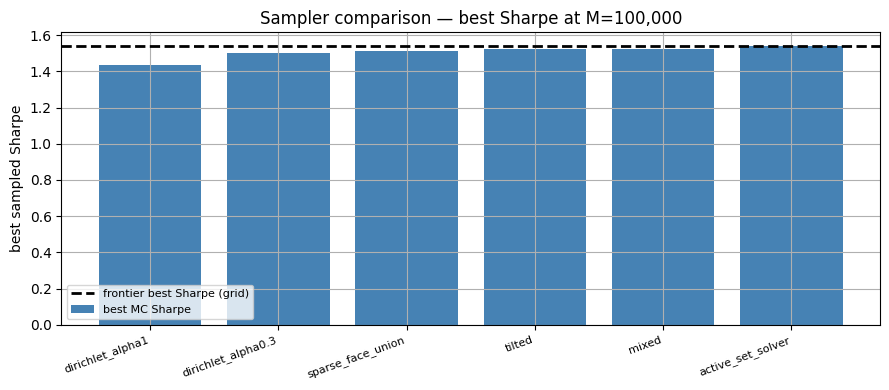

In [44]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(comp_df))
ax.bar(x, comp_df["best_sharpe"], color="steelblue", label="best MC Sharpe")
ax.axhline(frontier_sharpe, color="black", lw=2, ls="--", label="frontier best Sharpe (grid)")
ax.set_xticks(x)
ax.set_xticklabels(comp_df["sampler"], rotation=20, ha="right", fontsize=8)
ax.set_ylabel("best sampled Sharpe")
ax.set_title(f"Sampler comparison — best Sharpe at M={M_CLOUD:,}")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_sampler_comparison.png", dpi=120)
plt.show()

Persist a downsampled cloud (5k rows per sampler) for downstream notebooks that want to plot or filter the full distribution.

In [45]:
cloud_parts = []
for name, (r, v, s, n, _, _) in sampler_results.items():
    df = pd.DataFrame({"sampler": name, "return": r, "volatility": v, "sharpe": s, "effective_n": n})
    cloud_parts.append(df.sample(n=min(5000, len(df)), random_state=0))
cloud_df = pd.concat(cloud_parts, ignore_index=True)
cloud_df.to_csv(RESULTS_DIR / "monte_carlo_cloud.csv", index=False)
print(f"cloud summary: {len(cloud_df)} rows × {len(cloud_df.columns)} cols")

cloud summary: 25000 rows × 5 cols


## Target-Risk Comparison

At fixed volatility caps $\sigma_\star$ the best Monte Carlo return achievable subject to $\sigma_p \le \sigma_\star$ is compared with the best $\gamma$-grid frontier return at the same cap. The **return gap** is what random search loses to the solver at that risk budget.

In [46]:
sigma_grid = np.linspace(
    frontier_df["volatility"].min() * 1.01,
    frontier_df["volatility"].max() * 0.99,
    8,
)


def frontier_return_at_sigma(sigma_star):
    sub = frontier_df[frontier_df["volatility"] <= sigma_star]
    return float(sub["return"].max()) if len(sub) > 0 else np.nan


tr_rows = []
for name, (r, v, s, n, _, _) in sampler_results.items():
    for sig in sigma_grid:
        mask = v <= sig
        if mask.any():
            idx_best = int(np.argmax(np.where(mask, r, -np.inf)))
            mc_ret = float(r[idx_best])
            mc_vol = float(v[idx_best])
            mc_shr = float(mc_ret / mc_vol) if mc_vol > 0 else np.nan
        else:
            mc_ret = mc_vol = mc_shr = np.nan
        fr_ret = frontier_return_at_sigma(sig)
        tr_rows.append({
            "sampler":             name,
            "target_volatility":   float(sig),
            "mc_return":           mc_ret,
            "mc_volatility":       mc_vol,
            "frontier_return":     fr_ret,
            "frontier_volatility": float(sig),
            "return_gap":          float(fr_ret - mc_ret) if not np.isnan(mc_ret) else np.nan,
            "mc_sharpe":           mc_shr,
            "frontier_sharpe":     float(fr_ret / sig) if not np.isnan(fr_ret) else np.nan,
        })

tr_df = pd.DataFrame(tr_rows)
tr_df.to_csv(RESULTS_DIR / "monte_carlo_target_risk_comparison.csv", index=False)
print(tr_df.groupby("sampler")[["return_gap"]].mean().round(4))

                    return_gap
sampler                       
dirichlet_alpha0.3      0.0145
dirichlet_alpha1        0.0496
mixed                   0.0023
sparse_face_union       0.0037
tilted                  0.0093


## Convergence Study

Random search accuracy depends on sample size. As $M$ grows the chance of drawing close to the boundary improves, but sub-linearly: doubling $M$ does not halve the gap. Compare blind Dirichlet $\alpha = 1$ against the tilted and mixed samplers at five sample sizes.

Use one large draw per sampler and read best Sharpe on nested prefixes — guarantees the curve is monotone non-decreasing in $M$.

In [47]:
M_GRID  = [1_000, 5_000, 10_000, 50_000, 100_000]
M_MAX   = max(M_GRID)
conv_rng = np.random.default_rng(seed=42)

conv_samplers = [
    ("dirichlet_alpha1", lambda rng, N, M: sample_dirichlet(rng, N, M, 1.0)),
    ("tilted",           lambda rng, N, M: sample_tilted_dirichlet(rng, N, M, mu_hat, Sigma_hat)),
    ("mixed",            lambda rng, N, M: sample_mixed(rng, N, M, mu_hat, Sigma_hat)),
]

conv_rows = []
for label, draw_fn in conv_samplers:
    W_full = draw_fn(conv_rng, n_assets, M_MAX)
    r_full, v_full, s_full, _ = portfolio_metrics(W_full, mu_hat, Sigma_hat)
    s_safe = np.nan_to_num(s_full, nan=-np.inf)
    for M in M_GRID:
        bi = int(np.argmax(s_safe[:M]))
        conv_rows.append({
            "sampler":              label,
            "samples":              M,
            "best_mc_sharpe":       float(s_full[bi]),
            "best_mc_return":       float(r_full[bi]),
            "best_mc_volatility":   float(v_full[bi]),
            "frontier_best_sharpe": float(frontier_sharpe),
            "sharpe_gap":           float(frontier_sharpe - s_full[bi]),
        })
    print(f"{label}: M_max={M_MAX:,} draw complete")

conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv(RESULTS_DIR / "monte_carlo_convergence.csv", index=False)

dirichlet_alpha1: M_max=100,000 draw complete
tilted: M_max=100,000 draw complete
mixed: M_max=100,000 draw complete


Two-panel plot: best Sharpe vs $M$ on the left, Sharpe gap to frontier on the right.

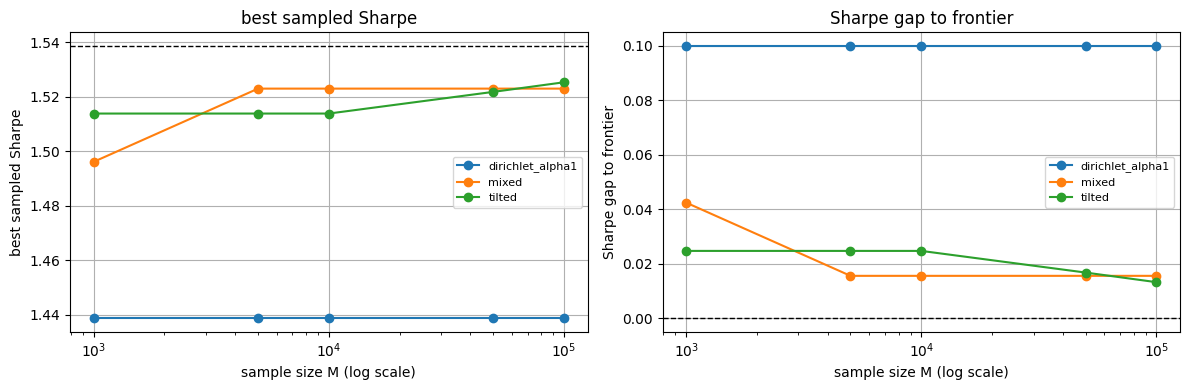

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, ylabel in [
    (axes[0], "best_mc_sharpe", "best sampled Sharpe"),
    (axes[1], "sharpe_gap",     "Sharpe gap to frontier"),
]:
    for label, grp in conv_df.groupby("sampler"):
        ax.plot(grp["samples"], grp[metric], marker="o", label=label)
    ax.axhline(frontier_sharpe if metric == "best_mc_sharpe" else 0,
               color="black", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_xlabel("sample size M (log scale)")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "monte_carlo_convergence.png", dpi=120)
plt.show()

## Interpretation

- **Boundary is measure-zero.** Dirichlet $\alpha = 1$ produces the worst Sharpe (1.433, gap 0.106 below frontier best of 1.539). Draws cluster around equal-weight ($N_{\text{eff}} \approx 9.9$); the corners of $\Delta_N$ — where the frontier lives — are almost never visited.
- **Concentration helps but is not monotone in $k$.** $\alpha = 0.3$ cuts the gap to 0.039; the sparse-face union cuts it further to 0.027. Within sparse face, however, $k = 5$ (gap 0.027) beats both $k = 2$ (gap 0.129 — *worse than $\alpha = 1$*) and $k = 8$ (gap 0.043). $k = 2$ fails because a 2-asset support space is too small to contain the actual tangency portfolio's support pattern.
- **Sharpe-aware sampling helps even more.** Tilted Dirichlet (gap 0.018) and the mixed sampler (gap 0.017) close in on the frontier by biasing toward assets with high $\hat\mu_i / \hat\sigma_i$ — cheap side information that blind samplers ignore. Mixed wins on both Sharpe and target-risk return gap (0.0023 vs tilted 0.0093, sparse 0.0037), but tilted alone is within run-to-run noise.
- **Solver beats Monte Carlo on every axis at $N = 20$.** Active-set solver: 0.027 s for 400 $\gamma$ points, gap = 0.0. Mixed sampler: 0.229 s for $10^5$ draws, gap = 0.017. Random search costs roughly 10× more wall time and still leaves a ≈ 1% Sharpe gap. Monte Carlo is the right tool only when the feasible region is non-convex or no solver exists.
- **$\alpha = 1$ does not converge in this range.** The convergence study shows the best Dirichlet $\alpha = 1$ Sharpe stuck at 1.4386 from $M = 1{,}000$ all the way to $M = 100{,}000$ — interior-clustered draws never reach a better corner in $10^5$ samples. Tilted and mixed both improve with $M$ but plateau by $M \approx 5{,}000$ on this seed.

## Limitations

- Estimation error in $\hat\mu$ and $\hat\Sigma$ is out of scope. This notebook quantifies *random-search* approximation error for fixed inputs.
- Sampler performance ranks by best-sample statistics, which are seed-dependent. The qualitative ranking is stable across seeds at the budgets tested; the exact numbers shift.
- The tilted sampler uses $\hat\mu / \hat\sigma$ at sample time, which is data-aware: it is not a uniform sampler on $\Delta_N$. Its low Sharpe gap reflects partial knowledge of the solution, not the strength of pure random search.
- Convergence behaviour is universe-dependent. At $N = 20$ the tangency portfolio's support is small (mostly two assets), so concentrated samplers find it quickly. At larger $N$ or wider support, all five samplers degrade.
- Monte Carlo is not a substitute for a convex solver on the long-only mean-variance problem. It is useful when the feasible region is non-convex or no solver is available.